# 09a – Multiplicity-Blind Gaussian Baseline: σ Parameter Optimisation

Multiplicity-blind control for the signed Gaussian baseline: every signal is treated as
**positive** (CH₂ peaks lose their negative sign), so the Gaussian representation carries
only chemical-shift information and no DEPT phase information. The gap to `03b` quantifies
how much retrieval performance comes from multiplicity encoding.

## Two variants

Blinding can be applied in two places — the **scoring** and the **candidate prefilter** —
and the two must be separated or the comparison to `03b` confounds "lost sign information"
with "different candidate pool". This notebook runs both:

| Variant | Prefilter | Isolates |
| --- | --- | --- |
| `gaussian_multiplicity_blind` | blind (`match_multiplicity=False`) | the end-to-end blind pipeline |
| `gaussian_multiplicity_blind_matched_prefilter` | identical to `03b` (`match_multiplicity=True`, **signed** shifts) | the scoring change alone |

## Notes on interpretation

- After `abs()`, a CH and a CH₂ at the same shift **reinforce** instead of cancelling, so
  scores are bounded in [0, 1] rather than [−1, 1]. This is the intended effect of blinding,
  not a bug.
- Blinding makes spectra far less discriminative, so many more candidates **tie** at
  identical cosine scores. A tie-break that happens to favour the true compound would
  flatter this baseline. Ranks are therefore reported with **pessimistic / standard /
  optimistic** tie bounds, using the same definitions as
  [`scripts/exp_tie_aware_hits.py`](../scripts/exp_tie_aware_hits.py) (Figure 2 whiskers).
  Note 04's claim that "Gaussian has no exact ties" is about the *signed* Gaussian and is
  not assumed here.
- `03b` is deliberately left untouched, so its numbers stay identical to the ones already
  in the manuscript. It ranks with `np.argsort`'s default (quicksort) while this notebook
  uses a stable sort — see the tie-break caveat printed by section 8 for why that does not
  materially affect the comparison.
- Section 8 compares against `03b`'s summary and **asserts** both runs used the same query
  set, so a stale artifact can never be silently differenced.

## 0 · Imports

In [1]:
import ast
import os

# Silence tqdm progress bars (incl. the library prefilter's) — the parallel
# sweep runs in a few minutes, so the bars add noise without much value.
os.environ["TQDM_DISABLE"] = "1"

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm

from dept_similarity.constants import PROCESSED_DATA_DIR, RESULTS_DIR
from dept_similarity.gaussian_vector import generate_gaussian_vector
from dept_similarity.prepare import prefilter_pairs_by_peak_overlap
from dept_similarity.utils import normalize_spectra_columns

tqdm.pandas()

## 1 · Load data

Loads `library_data.parquet` and `experimental_validation_set.parquet`, normalizes
`signed_shifts` to float arrays, then builds a reproducible random query subset
from unique molecules (`QUERY_SUBSET_SIZE`, `RANDOM_SEED`) — same order of operations as
`03b`, so the two runs produce the same `query_id` set.

`signed_shifts` is left **signed** (it is what the `03b`-matched prefilter needs); the
blinded copy lives in a separate `blind_shifts` column and is what the Gaussian scoring uses.

In [2]:
library_spectra_df = pd.read_parquet(f"{PROCESSED_DATA_DIR}/library_data.parquet")
query_spectra_df = pd.read_parquet(f"{PROCESSED_DATA_DIR}/experimental_validation_set.parquet")

# The Zenodo dump labels some columns differently (e.g. intensity_signed / inchikey_14);
# normalize to the canonical names 01a writes. Raises if a column is genuinely absent.
library_spectra_df = normalize_spectra_columns(
    library_spectra_df, required=("signed_shifts", "inchikey14")
)
query_spectra_df = normalize_spectra_columns(
    query_spectra_df, required=("signed_shifts", "inchikey14")
)


def _to_float_array(v):
    if isinstance(v, np.ndarray):
        return v.astype(np.float32, copy=False)
    if isinstance(v, list):
        return np.asarray(v, dtype=np.float32)
    if isinstance(v, str):
        v = v.strip()
        if not v:
            return np.asarray([], dtype=np.float32)
        try:
            parsed = ast.literal_eval(v)
        except (ValueError, SyntaxError):
            parsed = []
        return np.asarray(parsed, dtype=np.float32)
    if pd.isna(v):
        return np.asarray([], dtype=np.float32)
    return np.asarray(v, dtype=np.float32)


library_spectra_df["signed_shifts"] = library_spectra_df["signed_shifts"].map(_to_float_array)
query_spectra_df["signed_shifts"] = query_spectra_df["signed_shifts"].map(_to_float_array)

# Multiplicity-blind shifts live in their OWN column: dropping the CH2 sign makes every
# peak a positive Gaussian. `signed_shifts` stays signed because the 03b-matched prefilter
# variant needs the real signs — blinding it in place would silently blind that arm too.
library_spectra_df["blind_shifts"] = library_spectra_df["signed_shifts"].map(np.abs)
query_spectra_df["blind_shifts"] = query_spectra_df["signed_shifts"].map(np.abs)

# None → use the full validation set (all unique-molecule queries). Set an int to subsample.
QUERY_SUBSET_SIZE = None
RANDOM_SEED = 42

query_unique_df = query_spectra_df.drop_duplicates(subset=["inchikey"]).copy()
if QUERY_SUBSET_SIZE is not None:
    if len(query_unique_df) < QUERY_SUBSET_SIZE:
        raise ValueError(
            f"Need at least {QUERY_SUBSET_SIZE} unique query molecules, found {len(query_unique_df)}"
        )
    query_spectra_df = query_unique_df.sample(
        n=QUERY_SUBSET_SIZE, random_state=RANDOM_SEED
    ).reset_index(drop=True)
else:
    query_spectra_df = query_unique_df.reset_index(drop=True)

assert query_spectra_df["blind_shifts"].map(lambda a: (a >= 0).all()).all()
assert library_spectra_df["blind_shifts"].map(lambda a: (a >= 0).all()).all()

print(
    {
        "library_rows": len(library_spectra_df),
        "query_rows": len(query_spectra_df),
        "query_unique_inchikeys": int(query_spectra_df["inchikey"].nunique()),
        "random_seed": RANDOM_SEED,
    }
)

{'library_rows': 455289, 'query_rows': 648, 'query_unique_inchikeys': 648, 'random_seed': 42}


## 2 · Pre-filter candidate pairs

Both candidate pools are built here so the two variants can be compared within a single run:

- **blind** — `match_multiplicity=False` on the all-positive `blind_shifts`; the untyped
  fingerprint is half the width, so a CH and a CH₂ at the same shift share a bit.
- **matched** — exactly `03b`: `match_multiplicity=True` on the **signed** shifts.

The diagnostics cell then reports pool size and true-match recall for each, which is what
makes the two σ sweeps interpretable side by side.

In [3]:
def _prefilter_view(df: pd.DataFrame, shift_col: str) -> pd.DataFrame:
    """Minimal 2-column frame in the shape prefilter_pairs_by_peak_overlap expects.

    Building a light view (rather than .assign on the 455k-row library) keeps peak
    RSS down, which matters because the sweep below forks one worker per core.
    """
    return pd.DataFrame(
        {
            "compound_id": df["compound_id"].to_numpy(),
            "signed_shifts": df[shift_col].to_numpy(),
        }
    )


# key → (shift column, match_multiplicity)
POOL_SPECS = {
    "blind": ("blind_shifts", False),
    "matched": ("signed_shifts", True),
}

POOLS: dict[str, dict] = {}
for _key, (_shift_col, _match_mult) in POOL_SPECS.items():
    POOLS[_key] = prefilter_pairs_by_peak_overlap(
        _prefilter_view(query_spectra_df, _shift_col),
        _prefilter_view(library_spectra_df, _shift_col),
        match_multiplicity=_match_mult,
    )
    print(f"  pool '{_key}': {len(POOLS[_key])} query molecules")

  pool 'blind': 648 query molecules


  pool 'matched': 648 query molecules


In [4]:
# Candidate-pool diagnostics — the evidence that the two sweeps are comparable.
#
# `recall` is the ceiling on Hits@K: a query whose true compound never entered its
# candidate set can never be retrieved, no matter how good the scoring is. If the two
# pools have very different recall, the Hits@K gap is partly a prefilter artifact and
# the "matched" variant is the one that isolates the scoring change.
#
# NB: we deliberately do NOT call validate_candidate_set() here — it *mutates* the dict,
# deleting queries whose true match was filtered out, which would silently change the
# denominator and inflate Hits@K.
_lib_ik = dict(zip(library_spectra_df["compound_id"], library_spectra_df["inchikey14"]))
_q_ik = dict(zip(query_spectra_df["compound_id"], query_spectra_df["inchikey14"]))

pool_rows = []
for key, pairs in POOLS.items():
    sizes = np.array([len(pairs.get(q, ())) for q in query_spectra_df["compound_id"]])
    found = sum(
        1
        for q in query_spectra_df["compound_id"]
        if _q_ik[q] in {_lib_ik.get(c) for c in pairs.get(q, ())}
    )
    pool_rows.append(
        {
            "pool": key,
            "match_multiplicity": POOL_SPECS[key][1],
            "queries": len(query_spectra_df),
            "mean candidates/query": sizes.mean(),
            "median candidates/query": float(np.median(sizes)),
            "empty pools": int((sizes == 0).sum()),
            "true-match recall (%)": 100.0 * found / len(query_spectra_df),
        }
    )

pool_df = pd.DataFrame(pool_rows).set_index("pool")
print(pool_df.to_string(float_format=lambda v: f"{v:,.1f}"))
print(
    "\nrecall = upper bound on Hits@K for that pool; a gap here is a prefilter effect, "
    "not a scoring effect."
)

         match_multiplicity  queries  mean candidates/query  median candidates/query  empty pools  true-match recall (%)
pool                                                                                                                    
blind                 False      648              179,752.8                182,647.5            1                   98.8
matched                True      648               98,793.9                 85,973.0            1                   98.6

recall = upper bound on Hits@K for that pool; a gap here is a prefilter effect, not a scoring effect.


## 3 · σ sweep configuration

Edit `SIGMA_VALUES` to add / remove candidates.  The current range
spans sub-peak (0.5 ppm) to wide-tolerance (6.0 ppm) regimes.

In [5]:
# --- Sweep parameters ---------------------------------------------------
SIGMA_VALUES: list[float] = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 5.0, 6.0]
K_VALUES: list[int] = [1, 5, 10]

# Two scores are counted as tied within this absolute tolerance — same constant as
# scripts/plot_tie_distribution.py, so the tie bounds here mean the same thing as
# the Figure 2 whiskers.
TIE_ATOL = 1e-9

# variant name (output dir) → candidate pool used
VARIANTS: dict[str, str] = {
    "gaussian_multiplicity_blind": "blind",
    "gaussian_multiplicity_blind_matched_prefilter": "matched",
}

OPT_ROOT = Path(RESULTS_DIR) / "optimization"

print(f"σ values to evaluate : {SIGMA_VALUES}")
print(f"Hits@K values        : {K_VALUES}")
print(f"Tie tolerance        : {TIE_ATOL:g}")
for _name, _pool in VARIANTS.items():
    print(f"Variant '{_pool}' → {OPT_ROOT / _name}")

σ values to evaluate : [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 5.0, 6.0]
Hits@K values        : [1, 5, 10]
Tie tolerance        : 1e-09
Variant 'blind' → ../data/results/optimization/gaussian_multiplicity_blind
Variant 'matched' → ../data/results/optimization/gaussian_multiplicity_blind_matched_prefilter


## 4 · Run the sweep

For each variant and each σ:
1. Build Gaussian vectors from the **all-positive** `blind_shifts` and score candidates with
   **cosine similarity** (batched dot product against a stacked candidate matrix).
2. Derive the rank of the true match under three tie-breaking regimes, compute Hits@K, and
   save each K to its sigma folder.

**Tie regimes** (definitions from [`scripts/exp_tie_aware_hits.py`](../scripts/exp_tie_aware_hits.py)):

| regime | rank of the true match |
| --- | --- |
| optimistic | `g + 1` — only candidates that *strictly* outscore it count |
| standard | position under a **stable** descending sort (arbitrary but reproducible) |
| pessimistic | `g + t + 1` — every non-true candidate tied with it is placed ahead |

where `g` = candidates scoring strictly above the best true-label candidate and `t` = non-true
candidates tied with it. Blinding creates many more exact ties, so the optimistic figure alone
would overstate this baseline; the pessimistic–optimistic band is the honest range.

In [6]:
# Parallel σ sweep — each query is an independent task scored across all σ.
#
# The hot function generate_gaussian_vector is numba-@njit without nogil, so it
# holds the GIL — a thread pool can't run it concurrently.  We use a joblib
# **fork-based** process pool (backend="multiprocessing"): on Linux the workers
# inherit the big library_peaks / query_peaks dicts copy-on-write, so each task
# only ships a tiny query-id string (no per-task array pickling) and all cores
# stay saturated.  The worker reads the shared lookups from module globals.
#
# That inheritance trick is fork-only.  Under spawn (macOS/Windows default) the
# worker cannot even unpickle a notebook-defined function, so fail loudly with a
# usable instruction instead of dying with a bare AttributeError.
import multiprocessing as mp

from joblib import Parallel, delayed

N_JOBS = -1  # -1 = all cores; lower it (e.g. 32) to be friendly on a shared box

if N_JOBS != 1 and "fork" not in mp.get_all_start_methods():
    raise RuntimeError(
        "The parallel path relies on fork-inherited globals, which this platform "
        "(macOS/Windows use 'spawn') does not support. Set N_JOBS = 1 above to run "
        "the sweep serially instead."
    )

# Precompute lookups once (inherited by the forked workers).
# blind_shifts holds the all-positive shifts, so every Gaussian gets +1 amplitude.
query_ids = query_spectra_df["compound_id"].tolist()
query_peaks = query_spectra_df.set_index("compound_id")["blind_shifts"].to_dict()
library_peaks = library_spectra_df.set_index("compound_id")["blind_shifts"].to_dict()
query_inchikey = query_spectra_df.set_index("compound_id")["inchikey14"].to_dict()
library_inchikey = library_spectra_df.set_index("compound_id")["inchikey14"].to_dict()

# Rebound per variant just before each Parallel() call, so the fork inherits the right pool.
all_pairs_dict: dict = {}


def _rank_with_tie_bounds(scores: np.ndarray, cand_keys: np.ndarray, true_ik) -> dict:
    """Rank of the true match under the standard / optimistic / pessimistic tie regimes."""
    is_true = cand_keys == true_ik
    if not is_true.any():
        return {"rank": np.inf, "rank_optimistic": np.inf, "rank_pessimistic": np.inf}

    # Standard: stable sort, so ties keep candidate insertion order — arbitrary but
    # reproducible across runs (plain argsort uses quicksort and is not).
    order = np.argsort(-scores, kind="stable")
    rank = int(np.flatnonzero(is_true[order])[0]) + 1

    # best_true is a Python float, so the comparisons below promote to float64 —
    # matching exp_tie_aware_hits.py, which casts scores to float before comparing.
    best_true = float(scores[is_true].max())
    n_strictly_better = int(np.sum(scores > best_true + TIE_ATOL))
    tied = np.abs(scores - best_true) <= TIE_ATOL
    n_non_true_tied = int(np.sum(tied & ~is_true))

    rank_optimistic = n_strictly_better + 1
    rank_pessimistic = n_strictly_better + n_non_true_tied + 1
    # The standard tie-break must land inside the bounds it is bracketed by; a
    # violation would mean the tie accounting and the sort disagree.
    assert rank_optimistic <= rank <= rank_pessimistic, (
        rank_optimistic,
        rank,
        rank_pessimistic,
    )

    return {
        "rank": rank,
        "rank_optimistic": rank_optimistic,
        "rank_pessimistic": rank_pessimistic,
    }


def _process_query(qid: str, sigma_values: list) -> dict:
    """Score one query against its candidates for every σ. Returns {σ: rank_row}.

    Reads the shared peak/inchikey lookups from module globals (inherited by the
    forked worker), so only ``qid`` crosses the process boundary.
    """
    cand_ids = list(all_pairs_dict.get(qid, []))
    true_ik = query_inchikey.get(qid)
    base = {"query_id": qid, "query_inchikey14": true_ik}

    out: dict = {}
    if not cand_ids:
        empty = {
            **base,
            "rank": np.inf,
            "rank_optimistic": np.inf,
            "rank_pessimistic": np.inf,
            "n_candidates": 0,
        }
        for sigma in sigma_values:
            out[sigma] = dict(empty)
        return out

    cand_keys = np.array([library_inchikey.get(c) for c in cand_ids], dtype=object)
    q_peaks = query_peaks[qid]

    for sigma in sigma_values:
        q_vec = generate_gaussian_vector(q_peaks, sigma=sigma)
        q_norm = float(np.linalg.norm(q_vec))

        cand_matrix = np.stack(
            [generate_gaussian_vector(library_peaks[cid], sigma=sigma) for cid in cand_ids]
        )
        cand_norms = np.linalg.norm(cand_matrix, axis=1)
        denom = cand_norms * q_norm
        scores = np.divide(
            cand_matrix @ q_vec,
            denom,
            out=np.zeros_like(denom, dtype=np.float32),
            where=denom > 0,
        )

        out[sigma] = {
            **base,
            **_rank_with_tie_bounds(scores, cand_keys, true_ik),
            "n_candidates": len(cand_ids),
        }
    return out


RANK_COLS = {"": "rank", "_opt": "rank_optimistic", "_pess": "rank_pessimistic"}
KEEP_COLS = [
    "query_id",
    "query_inchikey14",
    "n_candidates",
    "rank",
    "rank_optimistic",
    "rank_pessimistic",
]
summary_by_variant: dict[str, pd.DataFrame] = {}

for variant_name, pool_key in VARIANTS.items():
    print(f"\n=== {variant_name}  (pool: {pool_key}) ===")
    all_pairs_dict = POOLS[pool_key]  # forked workers inherit this binding
    opt_dir = OPT_ROOT / variant_name
    opt_dir.mkdir(parents=True, exist_ok=True)

    if N_JOBS == 1:
        per_query_results = [_process_query(qid, SIGMA_VALUES) for qid in query_ids]
    else:
        per_query_results = Parallel(n_jobs=N_JOBS, backend="multiprocessing")(
            delayed(_process_query)(qid, SIGMA_VALUES) for qid in query_ids
        )

    # Regroup rank rows by σ (query order preserved).
    ranks_by_sigma: dict[float, list[dict]] = {sigma: [] for sigma in SIGMA_VALUES}
    for per_query in per_query_results:
        for sigma, row in per_query.items():
            ranks_by_sigma[sigma].append(row)

    summary_rows: list[dict] = []
    for sigma in SIGMA_VALUES:
        sigma_dir = opt_dir / f"sigma_{sigma}"
        sigma_dir.mkdir(parents=True, exist_ok=True)

        results_df = pd.DataFrame(ranks_by_sigma[sigma])
        row: dict = {"sigma": sigma}

        for k in K_VALUES:
            hits_df = results_df[KEEP_COLS].copy()
            for suffix, rank_col in RANK_COLS.items():
                hits_col = f"hits_at_{k}{suffix}"
                hits_series = (results_df[rank_col] <= k).astype(int)
                hits_df[hits_col] = hits_series
                row[hits_col] = hits_series.mean() * 100
            hits_df.to_parquet(sigma_dir / f"hits_at_{k}.parquet", index=False)

        summary_rows.append(row)
        print(
            f"  sigma={sigma:.1f} ppm -> "
            + "  ".join(
                f"Hits@{k}: {row[f'hits_at_{k}']:.1f}% "
                f"[{row[f'hits_at_{k}_pess']:.1f}–{row[f'hits_at_{k}_opt']:.1f}]"
                for k in K_VALUES
            )
        )

    summary_by_variant[variant_name] = pd.DataFrame(summary_rows).set_index("sigma")


=== gaussian_multiplicity_blind  (pool: blind) ===


  sigma=0.5 ppm -> Hits@1: 32.7% [32.7–32.7]  Hits@5: 45.8% [45.8–45.8]  Hits@10: 52.2% [52.2–52.2]
  sigma=1.0 ppm -> Hits@1: 47.7% [47.7–47.7]  Hits@5: 60.5% [60.5–60.5]  Hits@10: 65.4% [65.4–65.4]
  sigma=1.5 ppm -> Hits@1: 53.2% [53.2–53.2]  Hits@5: 65.1% [65.1–65.1]  Hits@10: 69.6% [69.6–69.6]
  sigma=2.0 ppm -> Hits@1: 53.1% [53.1–53.1]  Hits@5: 68.2% [68.2–68.2]  Hits@10: 72.4% [72.4–72.4]
  sigma=2.5 ppm -> Hits@1: 54.0% [54.0–54.0]  Hits@5: 69.0% [69.0–69.0]  Hits@10: 73.6% [73.6–73.6]
  sigma=3.0 ppm -> Hits@1: 53.2% [53.2–53.2]  Hits@5: 69.0% [69.0–69.0]  Hits@10: 73.5% [73.5–73.5]
  sigma=3.5 ppm -> Hits@1: 52.3% [52.3–52.3]  Hits@5: 67.6% [67.6–67.6]  Hits@10: 73.6% [73.6–73.6]
  sigma=4.0 ppm -> Hits@1: 52.2% [52.2–52.2]  Hits@5: 66.5% [66.5–66.5]  Hits@10: 72.5% [72.4–72.5]
  sigma=5.0 ppm -> Hits@1: 47.4% [47.4–47.4]  Hits@5: 63.6% [63.6–63.6]  Hits@10: 69.6% [69.6–69.6]
  sigma=6.0 ppm -> Hits@1: 43.7% [43.7–43.7]  Hits@5: 61.1% [61.1–61.1]  Hits@10: 67.0% [67.0–67.0]


  sigma=0.5 ppm -> Hits@1: 33.8% [33.8–33.8]  Hits@5: 48.5% [48.5–48.5]  Hits@10: 54.8% [54.8–54.8]
  sigma=1.0 ppm -> Hits@1: 48.6% [48.6–48.6]  Hits@5: 62.8% [62.8–62.8]  Hits@10: 66.7% [66.7–66.7]
  sigma=1.5 ppm -> Hits@1: 53.5% [53.5–53.5]  Hits@5: 66.4% [66.4–66.4]  Hits@10: 71.0% [71.0–71.0]
  sigma=2.0 ppm -> Hits@1: 53.9% [53.9–53.9]  Hits@5: 69.3% [69.3–69.3]  Hits@10: 73.6% [73.6–73.6]
  sigma=2.5 ppm -> Hits@1: 55.2% [55.2–55.2]  Hits@5: 69.8% [69.8–69.8]  Hits@10: 74.5% [74.5–74.5]
  sigma=3.0 ppm -> Hits@1: 54.8% [54.8–54.8]  Hits@5: 70.4% [70.4–70.4]  Hits@10: 75.0% [75.0–75.0]
  sigma=3.5 ppm -> Hits@1: 53.5% [53.5–53.5]  Hits@5: 69.4% [69.4–69.4]  Hits@10: 75.0% [75.0–75.0]
  sigma=4.0 ppm -> Hits@1: 53.5% [53.5–53.5]  Hits@5: 68.8% [68.8–68.8]  Hits@10: 74.2% [74.1–74.2]
  sigma=5.0 ppm -> Hits@1: 49.5% [49.5–49.5]  Hits@5: 65.4% [65.4–65.4]  Hits@10: 71.6% [71.6–71.6]
  sigma=6.0 ppm -> Hits@1: 45.2% [45.2–45.2]  Hits@5: 63.3% [63.3–63.3]  Hits@10: 68.5% [68.5–68.5]


## 5 · Summary table

In [7]:
def _pretty(summary: pd.DataFrame) -> pd.DataFrame:
    """hits_at_5_pess → 'Hits@5 (%) pess', in K order with standard first."""
    cols = {}
    for k in K_VALUES:
        cols[f"hits_at_{k}"] = f"Hits@{k} (%)"
        cols[f"hits_at_{k}_pess"] = f"Hits@{k} pess"
        cols[f"hits_at_{k}_opt"] = f"Hits@{k} opt"
    return summary[list(cols)].rename(columns=cols)


for variant_name, summary in summary_by_variant.items():
    summary_path = OPT_ROOT / variant_name / "summary_hits_at_k.parquet"
    summary.reset_index().to_parquet(summary_path, index=False)
    print(f"Summary saved → {summary_path}")

# The end-to-end blind baseline is the headline variant.
summary_df = summary_by_variant["gaussian_multiplicity_blind"]
_pretty(summary_df).style.highlight_max(axis=0, color="lightgreen")

Summary saved → ../data/results/optimization/gaussian_multiplicity_blind/summary_hits_at_k.parquet
Summary saved → ../data/results/optimization/gaussian_multiplicity_blind_matched_prefilter/summary_hits_at_k.parquet


,Hits@1 (%),Hits@1 pess,Hits@1 opt,Hits@5 (%),Hits@5 pess,Hits@5 opt,Hits@10 (%),Hits@10 pess,Hits@10 opt
sigma,,,,,,,,,
0.500000,32.716049,32.716049,32.716049,45.833333,45.833333,45.833333,52.160494,52.160494,52.160494
1.000000,47.685185,47.685185,47.685185,60.493827,60.493827,60.493827,65.432099,65.432099,65.432099
1.500000,53.240741,53.240741,53.240741,65.123457,65.123457,65.123457,69.598765,69.598765,69.598765
2.000000,53.086420,53.086420,53.086420,68.209877,68.209877,68.209877,72.376543,72.376543,72.376543
2.500000,54.012346,54.012346,54.012346,68.981481,68.981481,68.981481,73.611111,73.611111,73.611111
3.000000,53.240741,53.240741,53.240741,68.981481,68.981481,68.981481,73.456790,73.456790,73.456790
3.500000,52.314815,52.314815,52.314815,67.592593,67.592593,67.592593,73.611111,73.611111,73.611111
4.000000,52.160494,52.160494,52.160494,66.512346,66.512346,66.512346,72.530864,72.376543,72.530864
5.000000,47.376543,47.376543,47.376543,63.580247,63.580247,63.580247,69.598765,69.598765,69.598765


## 6 · Quick visualisation

Figure saved → ../data/results/optimization/gaussian_multiplicity_blind/sigma_sweep_hits_at_k.png


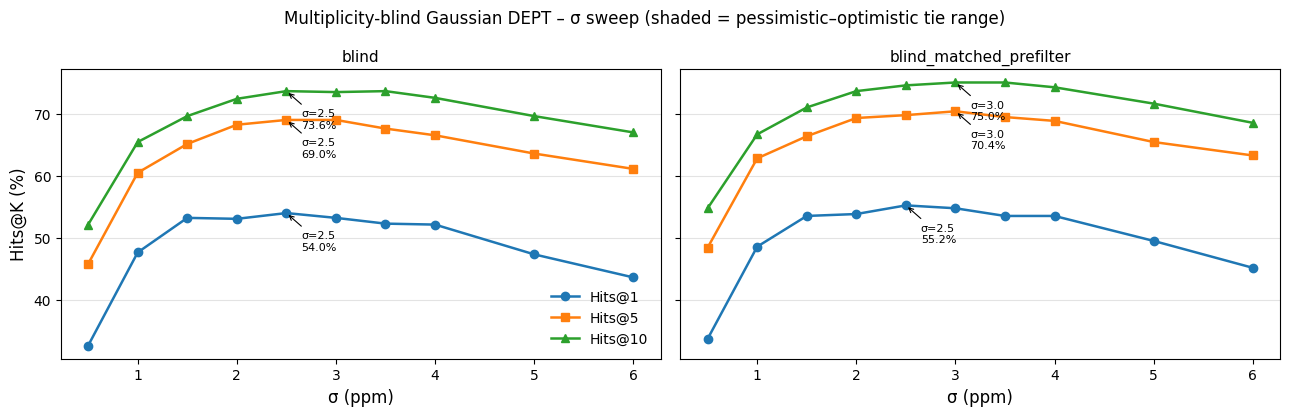

In [8]:
fig, axes = plt.subplots(1, len(VARIANTS), figsize=(13, 4.2), sharey=True)

markers = ["o", "s", "^"]  # one per K value
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for ax, (variant_name, summary) in zip(np.atleast_1d(axes), summary_by_variant.items()):
    for (k, marker), color in zip(zip(K_VALUES, markers), colors):
        ax.plot(
            summary.index,
            summary[f"hits_at_{k}"],
            marker=marker,
            color=color,
            label=f"Hits@{k}",
            linewidth=1.8,
        )
        # Shaded pessimistic–optimistic tie band: its width is how much of the
        # score depends on an arbitrary tie-break.
        ax.fill_between(
            summary.index,
            summary[f"hits_at_{k}_pess"],
            summary[f"hits_at_{k}_opt"],
            color=color,
            alpha=0.15,
            linewidth=0,
        )
        best_sigma = summary[f"hits_at_{k}"].idxmax()
        best_val = summary[f"hits_at_{k}"].max()
        ax.annotate(
            f"σ={best_sigma:.1f}\n{best_val:.1f}%",
            xy=(best_sigma, best_val),
            xytext=(best_sigma + 0.15, best_val - 6),
            fontsize=8,
            arrowprops=dict(arrowstyle="->", lw=0.8),
        )

    ax.set_xlabel("σ (ppm)", fontsize=12)
    ax.set_title(variant_name.replace("gaussian_multiplicity_blind", "blind"), fontsize=11)
    ax.grid(axis="y", alpha=0.35)

np.atleast_1d(axes)[0].set_ylabel("Hits@K (%)", fontsize=12)
np.atleast_1d(axes)[0].legend(frameon=False)
fig.suptitle(
    "Multiplicity-blind Gaussian DEPT – σ sweep (shaded = pessimistic–optimistic tie range)",
    fontsize=12,
)
fig.tight_layout()

fig_path = OPT_ROOT / "gaussian_multiplicity_blind" / "sigma_sweep_hits_at_k.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"Figure saved → {fig_path}")
plt.show()

## 7 · Identify optimal σ per K

In [9]:
for variant_name, summary in summary_by_variant.items():
    print(f"Optimal σ per metric — {variant_name}:")
    for k in K_VALUES:
        best_sigma = summary[f"hits_at_{k}"].idxmax()
        best = summary.loc[best_sigma]
        print(
            f"  Hits@{k:2d}: σ = {best_sigma:.1f} ppm  →  {best[f'hits_at_{k}']:.2f}%"
            f"  (tie range {best[f'hits_at_{k}_pess']:.2f}–{best[f'hits_at_{k}_opt']:.2f}%)"
        )
    print()

Optimal σ per metric — gaussian_multiplicity_blind:
  Hits@ 1: σ = 2.5 ppm  →  54.01%  (tie range 54.01–54.01%)
  Hits@ 5: σ = 2.5 ppm  →  68.98%  (tie range 68.98–68.98%)
  Hits@10: σ = 2.5 ppm  →  73.61%  (tie range 73.61–73.61%)

Optimal σ per metric — gaussian_multiplicity_blind_matched_prefilter:
  Hits@ 1: σ = 2.5 ppm  →  55.25%  (tie range 55.25–55.25%)
  Hits@ 5: σ = 3.0 ppm  →  70.37%  (tie range 70.37–70.37%)
  Hits@10: σ = 3.0 ppm  →  75.00%  (tie range 75.00–75.00%)



## 8 · Signed vs multiplicity-blind — the reviewer's number

Compares each variant against the **signed** Gaussian from `03b` at each arm's own optimal σ.

Both arms must come from the same query set, so this cell **asserts** that `03b`'s per-σ
rank files and this notebook's cover an identical `query_id` set. That guard exists because
the two are easy to desynchronise: `data/results/` is gitignored and the committed sweep was
once left behind by a regenerated validation set (1034 vs 648 queries), which would have made
the Δ meaningless. **If this raises, re-run `03b` before reading anything below.**

In [10]:
SIGNED_DIR = OPT_ROOT / "gaussian"
signed_summary_path = SIGNED_DIR / "summary_hits_at_k.parquet"

if not signed_summary_path.exists():
    raise FileNotFoundError(
        f"{signed_summary_path} not found — run 03b_gaussian_param_optimization.ipynb first; "
        "it produces the signed Gaussian baseline this section compares against."
    )

signed_summary = pd.read_parquet(signed_summary_path).set_index("sigma")


def _query_ids_of(opt_dir: Path) -> set:
    """query_id set of a sweep, read from a per-σ rank file (the summary has no ids)."""
    candidates = sorted(opt_dir.glob("sigma_*/hits_at_*.parquet"))
    if not candidates:
        raise FileNotFoundError(f"No per-σ rank files under {opt_dir}")
    return set(pd.read_parquet(candidates[0], columns=["query_id"])["query_id"])


signed_qids = _query_ids_of(SIGNED_DIR)
blind_qids = _query_ids_of(OPT_ROOT / "gaussian_multiplicity_blind")

if signed_qids != blind_qids:
    raise AssertionError(
        "03b and 09a were run on different query sets — the comparison would be invalid.\n"
        f"  03b (signed): {len(signed_qids)} queries\n"
        f"  09a (blind):  {len(blind_qids)} queries\n"
        f"  only in 03b: {len(signed_qids - blind_qids)}, "
        f"only in 09a: {len(blind_qids - signed_qids)}\n"
        "Re-run 03b_gaussian_param_optimization.ipynb against the current validation set."
    )

print(f"✓ both arms cover the same {len(signed_qids)} queries\n")

rows = []
for k in K_VALUES:
    signed_col = f"Hits@{k} (%)"
    signed_best_sigma = signed_summary[signed_col].idxmax()
    signed_best = signed_summary.loc[signed_best_sigma, signed_col]

    for variant_name, summary in summary_by_variant.items():
        blind_best_sigma = summary[f"hits_at_{k}"].idxmax()
        best = summary.loc[blind_best_sigma]
        rows.append(
            {
                "K": k,
                "variant": variant_name.replace("gaussian_multiplicity_blind", "blind"),
                "signed σ": signed_best_sigma,
                "signed Hits@K (%)": signed_best,
                "blind σ": blind_best_sigma,
                "blind Hits@K (%)": best[f"hits_at_{k}"],
                "Δ (pp)": best[f"hits_at_{k}"] - signed_best,
                "blind tie range (%)": (
                    f"{best[f'hits_at_{k}_pess']:.1f}–{best[f'hits_at_{k}_opt']:.1f}"
                ),
            }
        )

comparison_df = pd.DataFrame(rows)
comparison_path = OPT_ROOT / "gaussian_multiplicity_blind" / "signed_vs_blind.parquet"
comparison_df.to_parquet(comparison_path, index=False)

print(comparison_df.to_string(index=False, float_format=lambda v: f"{v:.2f}"))
print(f"\nSaved → {comparison_path}")
print(
    "\nΔ is blind − signed, in percentage points (negative = multiplicity encoding helps).\n"
    "'blind' = fully blind pipeline; 'blind_matched_prefilter' isolates the scoring change.\n"
    "\n"
    "Tie-break caveat: 03b is left exactly as the published numbers were produced, ranking\n"
    "with np.argsort's default (quicksort); this notebook uses a stable sort. The two\n"
    "'standard' columns therefore break tied scores differently. That only bites where ties\n"
    "actually occur, which is itself the asymmetry being measured — the signed Gaussian is a\n"
    "continuous score with essentially no exact ties (notebook 04), whereas blinding creates\n"
    "many. The 'blind tie range' column bounds the effect on the blind side; quote the range\n"
    "rather than the point estimate wherever that band is wide."
)

✓ both arms cover the same 648 queries

 K                 variant  signed σ  signed Hits@K (%)  blind σ  blind Hits@K (%)  Δ (pp) blind tie range (%)
 1                   blind      2.00              54.94     2.50             54.01   -0.93           54.0–54.0
 1 blind_matched_prefilter      2.00              54.94     2.50             55.25    0.31           55.2–55.2
 5                   blind      2.00              69.60     2.50             68.98   -0.62           69.0–69.0
 5 blind_matched_prefilter      2.00              69.60     3.00             70.37    0.77           70.4–70.4
10                   blind      2.50              75.00     2.50             73.61   -1.39           73.6–73.6
10 blind_matched_prefilter      2.50              75.00     3.00             75.00    0.00           75.0–75.0

Saved → ../data/results/optimization/gaussian_multiplicity_blind/signed_vs_blind.parquet

Δ is blind − signed, in percentage points (negative = multiplicity encoding helps).
'blind' 